In [154]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
import requests
import xml.etree.ElementTree as ET


# https://documenter.getpostman.com/view/7009892/2s93JtP3F6  API documentatie, is niet heel duidelijk
# https://transparency.entsoe.eu/  website waar je de data kan vinden om te vergelijken
key = "dd4684d5-ed6a-44f9-bad3-5c0d2def3831" # API key - user needs permission from entso-e
url = "https://web-api.tp.entsoe.eu/api"

In [155]:
# API response is in XML format, helemaal ruk, dit is mijn parsing functie. Als je de generation forcast queryd dan pakt ie gelijk de 24 uur van de dag, niet de timeframe die aangegeven is. Hou hier rekening mee als je de data gaat vergelijken
def parse_xml(xml):
  root = ET.fromstring(xml)

  points = []
  ns = {'ns': 'urn:iec62325.351:tc57wg16:451-6:generationloaddocument:3:0'}
  for point in root.findall('.//ns:Point', ns):
      position = int(point.find('ns:position', ns).text)
      quantity = point.find('ns:quantity', ns).text
      points.append({'position': len(points), 'quantity': quantity})
      # print(position, quantity)

  df = pd.DataFrame(points)
  return df

In [156]:
# https://transparencyplatform.zendesk.com/hc/en-us/articles/15885757676308-Area-List-with-Energy-Identification-Code-EIC   link naar alle codes
EIC_country_codes = {
    "10Y1001A1001A39I": "Estonia (EE)", 
    "10Y1001A1001A65H": "Denmark (DK)", 
    "10Y1001A1001A83F": "Germany (DE)", 
    "10Y1001A1001A92E": "United Kingdom (UK)",
    "10Y1001A1001A93C": "Malta (MT)",
    "10Y1001A1001A990": "Moldova (MD)",
    "10Y1001A1001B004": "Armenia (AM)",
    "10Y1001A1001B012": "Georgia (GE)",
    "10Y1001A1001B05V": "Azerbaijan (AZ)",
    "10Y1001C--00003F": "Ukraine (UA)",
    "10Y1001C--00100H": "Kosovo (XK)",
    "10YAL-KESH-----5": "Albania (AL)",
    "10YAT-APG------L": "Austria (AT)",
    "10YBA-JPCC-----D": "Bosnia and Herzegovina (BA)",
    "10YBE----------2": "Belgium (BE)",
    "10YCA-BULGARIA-R": "Bulgaria (BG)",
    "10YCH-SWISSGRIDZ": "Switzerland (CH)",
    "10YCS-CG-TSO---S": "Serbia (RS)",
    "10YCY-1001A0003J": "Cyprus (CY)",
    "10YCZ-CEPS-----N": "Czech Republic (CZ)",
    "10YES-REE------0": "Spain (ES)",
    "10YFI-1--------U": "Finland (FI)",
    "10YFR-RTE------C": "France (FR)",
    "10YGR-HTSO-----Y": "Greece (GR)",
    "10YHR-HEP------M": "Croatia (HR)",
    "10YHU-MAVIR----U": "Hungary (HU)",
    "10YIE-1001A00010": "Ireland (IE)",
    "10YIT-GRTN-----B": "Italy (IT)",
    "10YLT-1001A0008Q": "Lithuania (LT)",
    "10YLU-CEGEDEL-NQ": "Luxembourg (LU)",
    "10YLV-1001A00074": "Latvia (LV)",
    "10YMK-MEPSO----8": "North Macedonia (MK)",
    "10YNL----------L": "Netherlands (NL)",
    "10YNO-0--------C": "Norway (NO)",
    "10YPL-AREA-----S": "Poland (PL)",
    "10YPT-REN------W": "Portugal (PT)",
    "10YRO-TEL------P": "Romania (RO)",
    "10YSE-1--------K": "Sweden (SE)",
    "10YSI-ELES-----O": "Slovenia (SI)",
    "10YSK-SEPS-----K": "Slovakia (SK)",
    "10YTR-TEIAS----W": "Turkey (TR)",
    "BY": "Belarus (BY)",
    "IS": "Iceland (IS)",
    "RU": "Russia (RU)",
}

country_to_eic = {v: k for k, v in EIC_country_codes.items()} # reverse lookup

In [157]:
from datetime import datetime, timedelta

def get_week_period(year, week_number):
    """Returns periodStart and periodEnd for a given year and ISO week number."""
    # Find Monday of the given ISO week
    first_day_of_year = datetime(year, 1, 4)  # Jan 4 ensures we are in the first ISO week
    monday = first_day_of_year + timedelta(days=(week_number - 1) * 7 - first_day_of_year.weekday())

    # Adjust to previous Sunday 23:00 UTC (for periodStart)
    period_start = monday - timedelta(days=1)  # Previous Sunday
    period_start = period_start.replace(hour=23, minute=0)

    # End of the selected week (Sunday 23:00 UTC of the NEXT week)
    period_end = period_start + timedelta(days=7)

    return {
        "label": f"Week {week_number}, {year}: {period_start.strftime('%d %b %Y')} - {period_end.strftime('%d %b %Y')}",
        "periodStart": period_start.strftime("%Y%m%d%H%M"),
        "periodEnd": period_end.strftime("%Y%m%d%H%M"),
    }

In [ ]:
documentType = "A65" #load
processType="A16"

# Enter a year and week number to get the corresponding data
year = int(input("Enter a year (e.g., 2025): "))
week_number = int(input("Enter an ISO week number (1-53): "))

# Get the period
selected_week = get_week_period(year, week_number)

# Set periodStart and periodEnd
# met testen kwam ik erachter dat er tijd verschil is: 1 maart 00:00 wordt 202502282300 (28 februari 23:00)       -      (format: YYYYMMDDHHMM)
periodStart = selected_week["periodStart"]
periodEnd = selected_week["periodEnd"]

# CHOOSE COUNTRY (needs dropdown (or alternative) implementation if used in frontend)
selected_country = "Denmark (DK)" 
outBiddingZone_Domain = country_to_eic.get(selected_country, None)


print(f"EIC Code for {selected_country}: {outBiddingZone_Domain}")

request_url = (f"{url}?documentType={documentType}&processType={processType}"
               f"&outBiddingZone_Domain={outBiddingZone_Domain}"
               f"&periodStart={periodStart}&periodEnd={periodEnd}"
               f"&securityToken={key}")


response = requests.request("GET", request_url)

xml = response.text

load = parse_xml(xml)
load.tail()

EIC Code for Denmark (DK): 10Y1001A1001A65H


,position,quantity
163,163,4263
164,164,4045
165,165,3868
166,166,3678
167,167,3534


In [159]:
documentType="A71" # scheduled generation
processType="A01" # day ahead pakt voledige dag, niet de tijd die je aangeeft

request_url = (f"{url}?documentType={documentType}&processType={processType}"
               f"&in_Domain={outBiddingZone_Domain}"
               f"&periodStart={periodStart}&periodEnd={periodEnd}"
               f"&securityToken={key}")

response = requests.request("GET", request_url)

xml = response.text
generation = parse_xml(xml)
generation.tail()

,position,quantity
163,163,3231
164,164,3233
165,165,3109
166,166,2878
167,167,2614


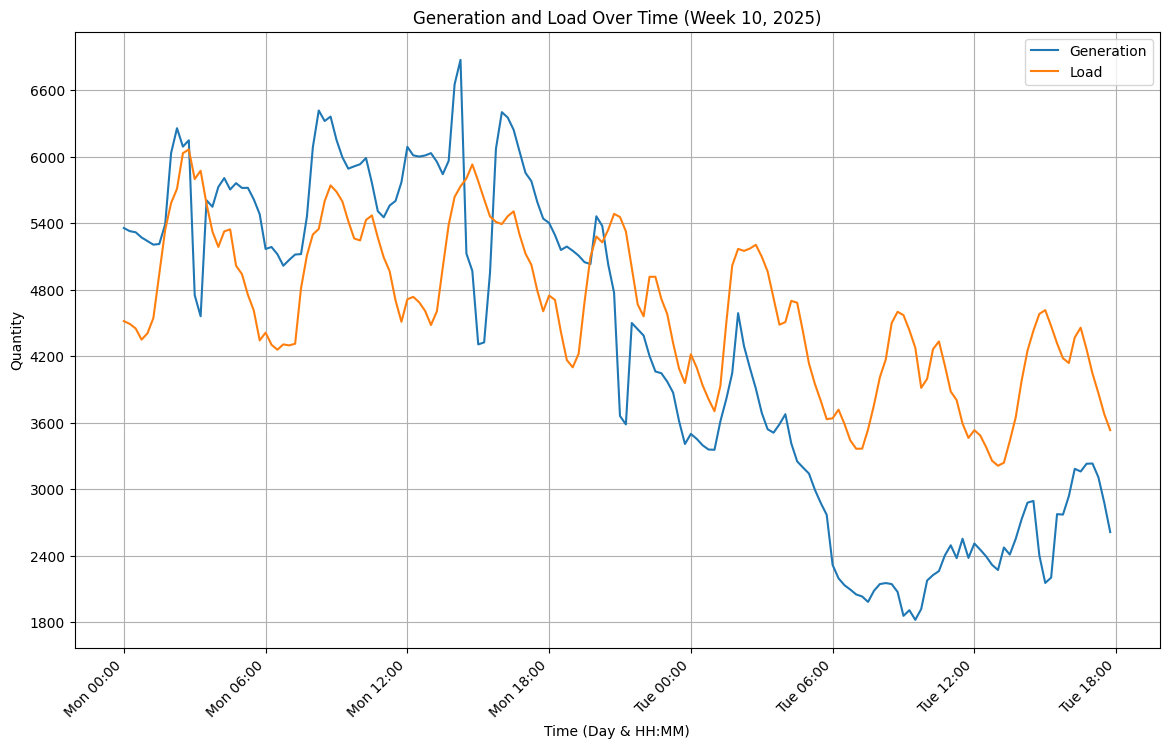

In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from datetime import datetime

# Convert (Year, Week) into a Monday date
start_date = datetime.strptime(f"{year}-W{week_number}-1", "%Y-W%W-%w")  # Monday 00:00 of the given ISO week

# Merge generation and load data
combination = pd.merge(generation, load, on='position', suffixes=('_generation', '_load'))

# Convert quantities to float
combination['quantity_generation'] = combination['quantity_generation'].astype(float)
combination['quantity_load'] = combination['quantity_load'].astype(float)

# Compute time column (adjusting for 15-minute intervals)
combination['time'] = start_date + pd.to_timedelta(combination['position'] * 15, unit='min')

# Plot
plt.figure(figsize=(14, 8))
plt.plot(combination['time'], combination['quantity_generation'], label='Generation')
plt.plot(combination['time'], combination['quantity_load'], label='Load')

ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Format x-axis to show "Day HH:MM"
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %H:%M'))  # Example: "Mon 12:00"

# Rotate labels for better readability
plt.xticks(rotation=45, ha='right')

# Add title with week and year info
plt.xlabel('Time (Day & HH:MM)')
plt.ylabel('Quantity')
plt.title(f"Generation and Load Over Time (Week {week_number}, {year})")
plt.legend()
plt.grid(True)
plt.show()


In [161]:
print(combination['quantity_load']>combination['quantity_generation'])

0      False
1      False
2      False
3      False
4      False
       ...  
163     True
164     True
165     True
166     True
167     True
Length: 168, dtype: bool


In [162]:
print(combination)

     position  quantity_generation  quantity_load                time
0           0               5358.0         4518.0 2025-03-10 00:00:00
1           1               5330.0         4493.0 2025-03-10 00:15:00
2           2               5320.0         4452.0 2025-03-10 00:30:00
3           3               5273.0         4351.0 2025-03-10 00:45:00
4           4               5241.0         4408.0 2025-03-10 01:00:00
..        ...                  ...            ...                 ...
163       163               3231.0         4263.0 2025-03-11 16:45:00
164       164               3233.0         4045.0 2025-03-11 17:00:00
165       165               3109.0         3868.0 2025-03-11 17:15:00
166       166               2878.0         3678.0 2025-03-11 17:30:00
167       167               2614.0         3534.0 2025-03-11 17:45:00

[168 rows x 4 columns]
